# Entraînement supervisé

Ce notebook permet d'effectuer un entraînement supervisé du réseau de neurones du joueur DL

In [3]:
import sys
sys.path.append('../onitama/')
from trainer import RegularDataTrainer
from dl_players_v6 import CNNPlayer_v6
import numpy as np
from livelossplot import PlotLossesKeras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import glob
import os


## Configuration

In [2]:
#Configuration
folder_data = "../data/"

In [4]:
#Boite à outils de fonctions

#Convertit une action ou un batch d'actions [col, ligne, action_id] en one-hot
def action_to_one_hot(action, shape=(5, 5, 52)):
    if isinstance(action, list) and len(action) == 3:
        # Une seule action
        col, ligne, action_id = action
        one_hot = np.zeros(shape, dtype=np.float32)
        one_hot[col, ligne, action_id] = 1.0
        return one_hot
    else:
        # Batch d'actions
        batch_size = len(action)
        one_hot_batch = np.zeros((batch_size, *shape), dtype=np.float32)
        
        for i, act in enumerate(action):
            col, ligne, action_id = act
            one_hot_batch[i, col, ligne, action_id] = 1.0
        
        return one_hot_batch

#Décode un un vecteur (1300,) en action [col, ligne, move_id]
def decode_flat_policy(flat_policy):
    #Trouver l'index du maximum (ou du 1.0 si one-hot)
    best_index = np.argmax(flat_policy)
    
    #Décoder l'index
    col = best_index // (5 * 52)
    ligne = (best_index // 52) % 5
    move_id = best_index % 52
    
    return [int(col), int(ligne), int(move_id)]


## Chargement et préparation des données

In [6]:
#Récupération des données

# Scanner le dossier et grouper par préfixe (nom de base sans suffixe)
states_files = sorted(glob.glob(os.path.join(folder_data, "*.states.pkl")))
basenames = [os.path.basename(f).replace(".states.pkl", "") for f in states_files]

policy_files = [os.path.join(folder_data, f"{b}.labels.pkl") for b in basenames]
mask_files   = [os.path.join(folder_data, f"{b}.mask.pkl")   for b in basenames]

# Vérifier que tous les fichiers existent
for s, p, m in zip(states_files, policy_files, mask_files):
    for path in [s, p, m]:
        if not os.path.exists(path):
            print(f"Fichier manquant : {path}")

print(f"{len(basenames)} jeu(x) de données trouvé(s) :")
for b in basenames:
    print(f"  - {b}")

states = []
policies = []
masks = []

for s_file, p_file, m_file in zip(states_files, policy_files, mask_files):
    states   += RegularDataTrainer.getTrainedData(filepath=s_file)
    policies += RegularDataTrainer.getTrainedData(filepath=p_file)
    masks    += RegularDataTrainer.getTrainedData(filepath=m_file)
    print(f"Chargé : {os.path.basename(s_file)}")

print("\n\nTotal :")
print(f"{len(states)} states")
print(f"{len(policies)} policies")
print(f"{len(masks)} masks")
print(f"{len(policies) / 18} jeux (approx.)")

# Filtrer les entrées dont le state n'a pas la shape attendue (10, 5, 5)
EXPECTED_SHAPE = (10, 5, 5)
valid = [np.array(s).shape == EXPECTED_SHAPE for s in states]
n_invalid = sum(1 for v in valid if not v)
if n_invalid > 0:
    print(f"{n_invalid} états ignorés (shape incorrecte)")
    states   = [s for s, v in zip(states,   valid) if v]
    policies = [p for p, v in zip(policies, valid) if v]
    masks    = [m for m, v in zip(masks,    valid) if v]

states = np.array(states)
print(states.shape)

states = np.transpose(states, (0, 2, 3, 1))
print(states.shape) #Maintenant on est bien (en 5,5,10)

6 jeu(x) de données trouvé(s) :
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive
  - LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_positional
  - LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_regular
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_defensive.states.pkl
Chargé : LookAheadHeuristic3heuristic_aggressive-vs-LookAheadHeuristic2heuristic_regular.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_aggressive.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-LookAheadHeuristic2heuristic_mobility.states.pkl
Chargé : LookAheadHeuristic3heuristic_defensive-vs-Look

In [7]:
#On applique one Hot Encoder sur les actions (policies)
policies = action_to_one_hot(policies)

In [8]:
#Aplatir pour correspondre à la sortie du modèle
policies = policies.reshape(-1, 5 * 5 * 52)  # (batch, 1300)

In [9]:
#Concatner avec les masques
masks = np.array(masks, dtype=np.float32)
y_masked = np.concatenate([policies, masks], axis=1)

In [10]:
# Mélange
indices = np.random.permutation(len(states))
states    = states[indices]
y_masked  = y_masked[indices]
print(f"Données mélangées : {len(states)} échantillons")

Données mélangées : 474458 échantillons


In [11]:
policies[0]

array([0., 0., 0., ..., 0., 0., 0.], shape=(1300,), dtype=float32)

## Chargement du modèle

In [12]:
network = CNNPlayer_v6(dropout_rate=0.2)

2026-04-15 22:15:17.007567: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [13]:
# Compiler pour supervised (gèle value head - spécifier d'utiliser les masques pour le calcul de la loss)
network.compile_for_supervised_policy(use_mask=True)

Gelé 10 layers de la tête de valeur
Modèle compilé pour entraînement supervisé (policy seulement, label_smoothing=0.1, weight_decay=0.0001, use_mask=True)


In [14]:
network.summary()

Model: "OnitamaNetwork-v6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state_input         │ (None, 5, 5, 10)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_input (Conv2D) │ (None, 5, 5, 128) │     11,648 │ state_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_input            │ (None, 5, 5, 128) │        512 │ conv_input[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ relu_input          │ (None, 5, 5, 128) │          0 │ bn_input[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_conv1   │ (None, 5, 5, 128) │    147,584 │ relu_input[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_bn1     │ (None, 5, 5, 128) │        512 │ res_block_0_conv… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_relu1   │ (None, 5, 5, 128) │          0 │ res_block_0_bn1[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_conv2   │ (None, 5, 5, 128) │    147,584 │ res_block_0_relu… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_bn2     │ (None, 5, 5, 128) │        512 │ res_block_0_conv… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_add     │ (None, 5, 5, 128) │          0 │ res_block_0_bn2[… │
│ (Add)               │                   │            │ relu_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_relu2   │ (None, 5, 5, 128) │          0 │ res_block_0_add[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_0_dropout │ (None, 5, 5, 128) │          0 │ res_block_0_relu… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_conv1   │ (None, 5, 5, 128) │    147,584 │ res_block_0_drop… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_bn1     │ (None, 5, 5, 128) │        512 │ res_block_1_conv… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_relu1   │ (None, 5, 5, 128) │          0 │ res_block_1_bn1[… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_conv2   │ (None, 5, 5, 128) │    147,584 │ res_block_1_relu… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res_block_1_bn2     │ (None, 5, 5, 128) │        512 │ res_block_1_conv… │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 1,631,621 (6.22 MB)

 Trainable params: 1,502,068 (5.73 MB)

 Non-trainable params: 129,553 (506.07 KB)

## Entraînement

In [15]:
#Finalisation des jeux

x_train  = states
y_value  = np.zeros((len(x_train), 1))

In [ ]:
y_policy = y_masked[:, :1300] 

In [ ]:

early_stop = EarlyStopping(
    monitor='val_policy_logits_accuracy',
    patience=5,
    restore_best_weights=True,
    mode='max'
)

checkpoint = ModelCheckpoint(
    filepath="../models/training/CNNPlayer-supervise-v6-best.weights.h5",
    monitor='val_policy_logits_accuracy',
    save_best_only=True,
    save_weights_only=True,
    mode='max',
    verbose=1
)

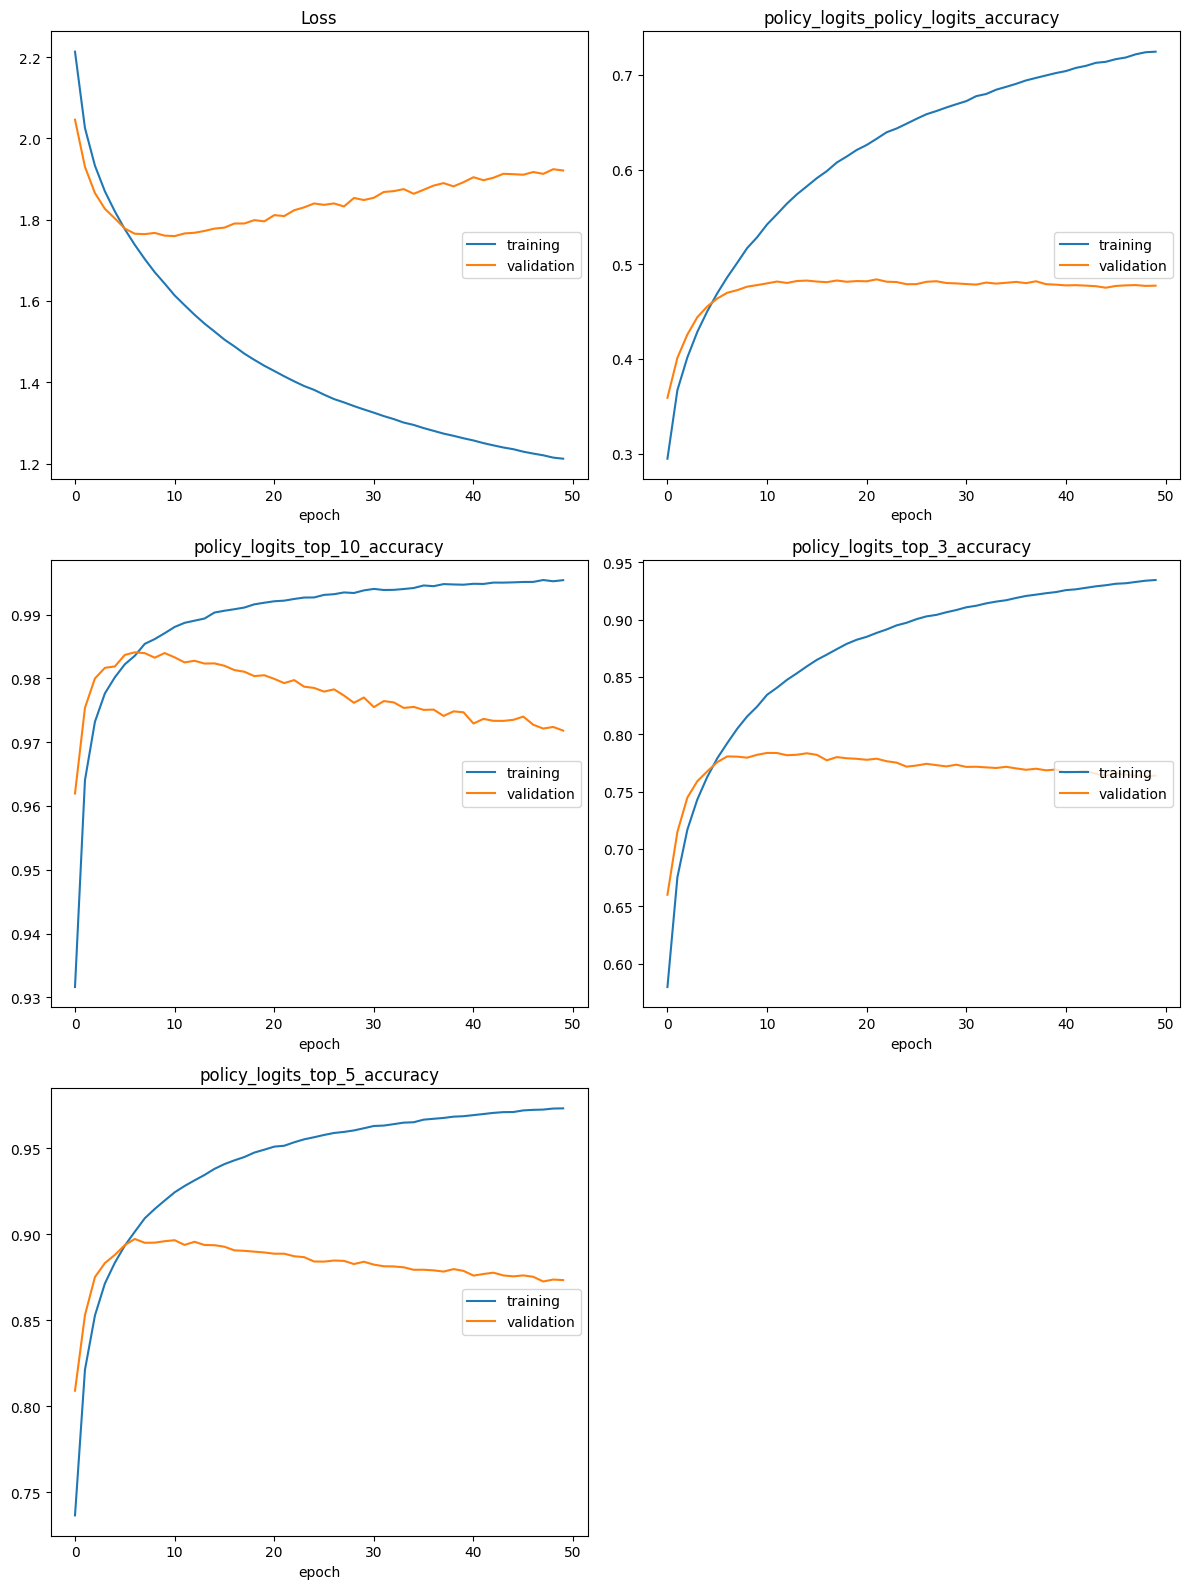

Loss
	training         	 (min:    1.212, max:    2.213, cur:    1.212)
	validation       	 (min:    1.760, max:    2.046, cur:    1.921)
policy_logits_policy_logits_accuracy
	training         	 (min:    0.295, max:    0.725, cur:    0.725)
	validation       	 (min:    0.359, max:    0.484, cur:    0.477)
policy_logits_top_10_accuracy
	training         	 (min:    0.932, max:    0.995, cur:    0.995)
	validation       	 (min:    0.962, max:    0.984, cur:    0.972)
policy_logits_top_3_accuracy
	training         	 (min:    0.580, max:    0.935, cur:    0.935)
	validation       	 (min:    0.660, max:    0.784, cur:    0.764)
policy_logits_top_5_accuracy
	training         	 (min:    0.737, max:    0.973, cur:    0.973)
	validation       	 (min:    0.809, max:    0.897, cur:    0.873)
5931/5931 ━━━━━━━━━━━━━━━━━━━━ 593s 100ms/step - loss: 1.2120 - policy_logits_policy_logits_accuracy: 0.7245 - policy_logits_top_10_accuracy: 0.9954 - policy_logits_top_3_accuracy: 0.9345 - policy_logits_top_5_

In [16]:
# Entraîner
history = network.fit(
    x_train,
    [y_masked, y_value],  # y_value sera ignoré - ici on utilise y_masked au lieu de y_policy
    batch_size=64,
    shuffle=True,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop, checkpoint, PlotLossesKeras()]
)